[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/07_optimization/notebooks/03_tarea_optimizacion.ipynb)

# Tarea 7: Optimización (20 puntos)

**Entrega:** Lunes 23 de febrero, 2026
**Formato:** Pull request en `estudiantes/<tu-usuario>/tarea_07/` + Canvas

## Instrucciones

Para **cada** problema (5 en total, 4 pts c/u):

| Pts | Qué hacer |
|:---:|-----------|
| 1 | **Formulación matemática** — escribe variables de decisión, función objetivo y restricciones en LaTeX |
| 1 | **Elección de optimizador** — elige el método/solver y explica por qué es adecuado |
| 1 | **Implementación** — completa las funciones esqueleto (las que tienen `raise NotImplementedError`) |
| 1 | **Solución y visualización** — ejecuta, reporta el resultado y visualiza |

**Reglas:**
- Completa SOLO las celdas marcadas con `raise NotImplementedError`
- NO modifiques las celdas de datos
- Escribe la matemática en LaTeX dentro de las celdas markdown indicadas
- Cada función tiene documentación con los inputs/outputs esperados

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (minimize, minimize_scalar, linprog, milp,
                            LinearConstraint, Bounds,
                            dual_annealing, differential_evolution)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

---
## Problema 1: Nutrición animal (4 puntos)

Un ganadero necesita formular la **dieta diaria** para su ganado. Dispone de 6 ingredientes, cada uno con un costo por kilogramo y un perfil nutricional conocido (energía, proteína, calcio, fósforo).

La dieta debe cumplir **requerimientos mínimos** de cada nutriente, y el **consumo total** debe estar entre 8 y 12 kg por animal. Cada ingrediente tiene un **límite máximo** de inclusión.

El objetivo es **minimizar el costo total** de la dieta diaria por animal.

| Ingrediente | Costo (\$/kg) | Energía (Mcal/kg) | Proteína (g/kg) | Calcio (g/kg) | Fósforo (g/kg) | Max (kg) |
|:-----------:|:------------:|:-----------------:|:---------------:|:------------:|:--------------:|:--------:|
| Maíz        | 4.5          | 3.3               | 90              | 0.3          | 2.8            | 6.0      |
| Soya        | 9.0          | 3.2               | 440             | 2.7          | 6.5            | 3.0      |
| Heno        | 2.5          | 2.0               | 80              | 4.0          | 2.0            | 5.0      |
| Melaza      | 3.0          | 2.8               | 40              | 8.0          | 0.8            | 2.0      |
| Minerales   | 15.0         | 0.0               | 0               | 200.0        | 80.0           | 0.5      |
| Salvado     | 3.5          | 2.5               | 150             | 1.5          | 12.0           | 4.0      |

**Requerimientos mínimos diarios por animal:** Energía >= 25 Mcal, Proteína >= 1000 g, Calcio >= 30 g, Fósforo >= 20 g

**Consumo total:** entre 8 y 12 kg

### 1.1 Formulacion matematica

**Variables de decision:**

Sea $x_i \ge 0$ la cantidad (kg) del ingrediente $i$ en la dieta diaria, para $i=1,\dots,6$.

$$x = (x_1,\dots,x_6)^\top$$


**Funcion objetivo:**

Minimizar el costo total diario:

$$\min_{x} \; \sum_{i=1}^6 c_i x_i$$

**Restricciones:**

$$\begin{aligned}
&\sum_{i=1}^6 a_{ki}x_i \ge r_k, \quad k=1,\dots,4 \quad \text{(requerimientos minimos de nutrientes)}\\
&8 \le \sum_{i=1}^6 x_i \le 12 \quad \text{(consumo total)}\\
&0 \le x_i \le \bar x_i, \quad i=1,\dots,6 \quad \text{(maximo por ingrediente)}
\end{aligned}$$

### 1.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**

**Justificacion (2-3 oraciones):**

In [2]:
# === DATOS PROBLEMA 1 (NO MODIFICAR) ===
nombres_p1 = ["Maiz", "Soya", "Heno", "Melaza", "Minerales", "Salvado"]
costos_p1 = np.array([4.5, 9.0, 2.5, 3.0, 15.0, 3.5])

# Contenido nutricional por kg: filas = [energia, proteina, calcio, fosforo]
nutrientes_p1 = np.array([
    [3.3, 3.2, 2.0, 2.8, 0.0, 2.5],   # energia (Mcal/kg)
    [90,  440, 80,  40,  0,   150],     # proteina (g/kg)
    [0.3, 2.7, 4.0, 8.0, 200, 1.5],    # calcio (g/kg)
    [2.8, 6.5, 2.0, 0.8, 80,  12.0],   # fosforo (g/kg)
])
nombres_nutrientes_p1 = ["Energia (Mcal)", "Proteina (g)", "Calcio (g)", "Fosforo (g)"]
req_min_p1 = np.array([25.0, 1000.0, 30.0, 20.0])
max_kg_p1 = np.array([6.0, 3.0, 5.0, 2.0, 0.5, 4.0])
intake_min_p1, intake_max_p1 = 8.0, 12.0

In [5]:
# === IMPLEMENTACION PROBLEMA 1 ===

def objetivo_p1(x):
    """Calcula el costo total de la dieta.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        float -- costo total de la dieta
    """
    x = np.asarray(x, dtype=float)
    return float(costos_p1 @ x)


def verificar_p1(x):
    """Verifica si la solucion cumple TODAS las restricciones.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        dict con:
          'factible': bool
          'nutrientes_totales': np.array (4,) -- aporte total de cada nutriente
          'intake_total': float -- kg totales
    """
    x = np.asarray(x, dtype=float)
    nutrientes_totales = nutrientes_p1 @ x
    intake_total = float(np.sum(x))

    tol = 1e-7
    cumple_nutrientes = np.all(nutrientes_totales + tol >= req_min_p1)
    cumple_intake = (intake_total >= intake_min_p1 - tol) and (intake_total <= intake_max_p1 + tol)
    cumple_cotas = np.all(x >= -tol) and np.all(x <= max_kg_p1 + tol)

    return {
        "factible": bool(cumple_nutrientes and cumple_intake and cumple_cotas),
        "nutrientes_totales": nutrientes_totales,
        "intake_total": intake_total,
    }


def resolver_p1():
    """Resuelve el problema de nutricion animal.

    Usa los datos globales (costos_p1, nutrientes_p1, etc.)
    y el optimizador que elegiste en la seccion 1.2.

    Returns:
        x_opt: np.array (6,) -- kg optimos de cada ingrediente
        costo_opt: float -- costo minimo
    """
    n = len(costos_p1)

    A_ub = []
    b_ub = []

    # nutrientes_p1 @ x >= req_min_p1  ->  -nutrientes_p1 @ x <= -req_min_p1
    A_ub.extend((-nutrientes_p1).tolist())
    b_ub.extend((-req_min_p1).tolist())

    # intake max
    A_ub.append(np.ones(n))
    b_ub.append(intake_max_p1)

    # intake min -> -sum(x) <= -intake_min
    A_ub.append(-np.ones(n))
    b_ub.append(-intake_min_p1)

    bounds = [(0, float(max_kg_p1[i])) for i in range(n)]

    res = linprog(
        c=costos_p1,
        A_ub=np.array(A_ub, dtype=float),
        b_ub=np.array(b_ub, dtype=float),
        bounds=bounds,
        method="highs"
    )

    if not res.success:
        raise RuntimeError(f"No se pudo resolver P1: {res.message}")

    x_opt = res.x
    costo_opt = float(res.fun)
    return x_opt, costo_opt

Solucion P1:
 Maiz: 0.407 kg
 Soya: 0.000 kg
 Heno: 5.000 kg
 Melaza: 2.000 kg
 Minerales: 0.000 kg
 Salvado: 3.222 kg
Costo total: $31.61
Intake total: 10.63 kg
Factible: True


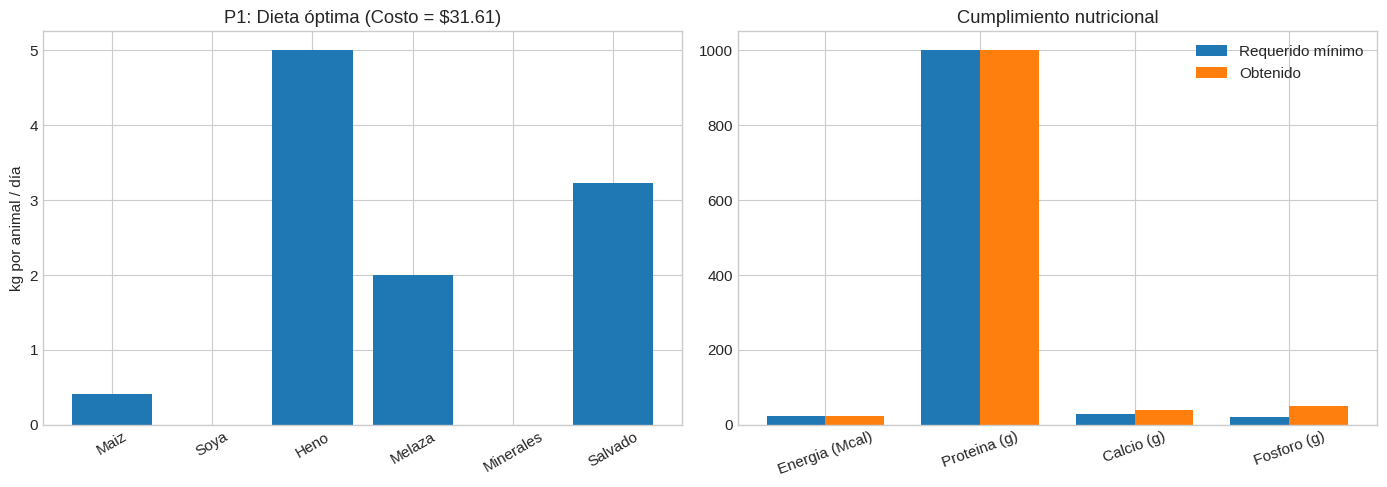

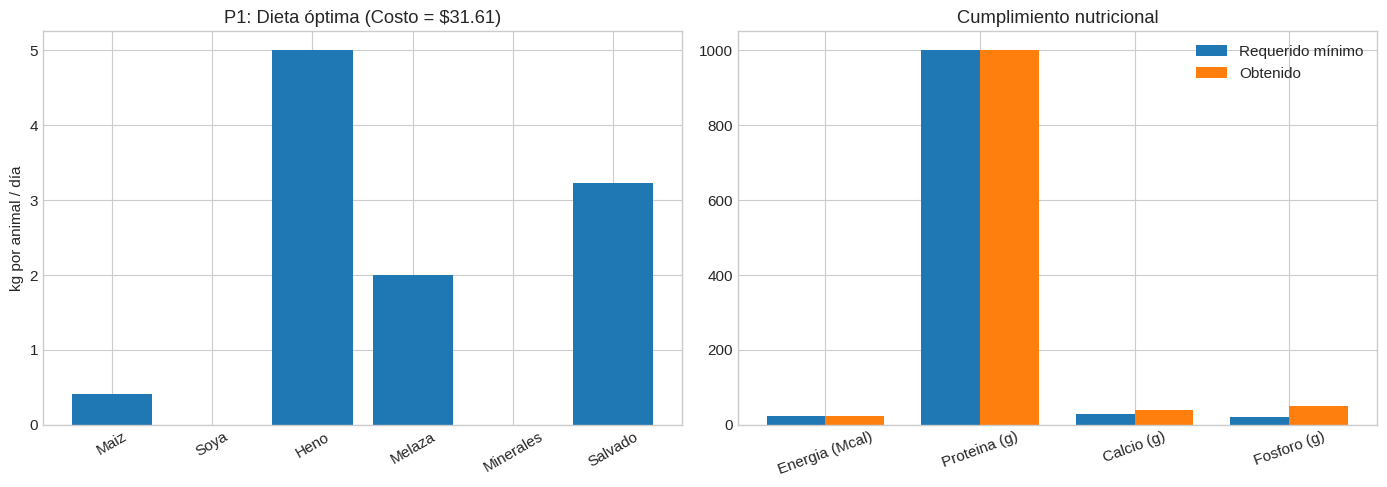

In [7]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 1 ===

def plot_p1(x_opt, costo_opt):
    """Visualiza la solucion del problema de nutricion.

    Debe mostrar:
    - Panel 1: Barras con kg de cada ingrediente
    - Panel 2: Barras comparando nutrientes obtenidos vs requeridos

    Args:
        x_opt: np.array (6,)
        costo_opt: float
    """
    info = verificar_p1(x_opt)
    nutrientes_totales = info["nutrientes_totales"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1
    axes[0].bar(nombres_p1, x_opt)
    axes[0].set_title(f"P1: Dieta óptima (Costo = ${costo_opt:.2f})")
    axes[0].set_ylabel("kg por animal / día")
    axes[0].tick_params(axis="x", rotation=30)

    # Panel 2
    idx = np.arange(len(req_min_p1))
    w = 0.38
    axes[1].bar(idx - w/2, req_min_p1, width=w, label="Requerido mínimo")
    axes[1].bar(idx + w/2, nutrientes_totales, width=w, label="Obtenido")
    axes[1].set_xticks(idx)
    axes[1].set_xticklabels(nombres_nutrientes_p1, rotation=20)
    axes[1].set_title("Cumplimiento nutricional")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Resolver y visualizar
x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print(f"Solucion P1:")
for nombre, kg in zip(nombres_p1, x_opt_p1):
    print(f" {nombre}: {kg:.3f} kg")
print(f"Costo total: ${costo_opt_p1:.2f}")
print(f"Intake total: {info_p1['intake_total']:.2f} kg")
print(f"Factible: {info_p1['factible']}")

plot_p1(x_opt_p1, costo_opt_p1)

plot_p1(x_opt_p1, costo_opt_p1)

---
## Problema 2: Portafolio de inversion (4 puntos)

Un inversionista tiene capital para distribuir entre 5 activos financieros. Cada activo tiene un **rendimiento esperado** y una **covarianza** conocida con los demas activos (ver datos).

El objetivo es **minimizar el riesgo** del portafolio (medido como la varianza del rendimiento), sujeto a:
- El rendimiento esperado del portafolio debe ser **al menos 8%**
- Todo el capital debe invertirse (las proporciones suman 1)
- No se permiten ventas en corto (todas las proporciones >= 0)
- Ningun activo puede representar mas del **40%** del portafolio

### 2.1 Formulacion matematica
**Variables de decision:**

Sea $w_i$ la proporcion del capital invertida en el activo $i$, para $i=1,\dots,5$.

$$w = (w_1,\dots,w_5)^\top$$

**Funcion objetivo:**

Minimizar la varianza del portafolio:

$$\min_{w} \; w^\top \Sigma w$$

donde $\Sigma$ es la matriz de covarianzas.

**Restricciones:**

$$\begin{aligned}
&\mu^\top w \ge 0.08 && \text{(rendimiento esperado minimo)}\\
&\sum_{i=1}^5 w_i = 1 && \text{(todo el capital se invierte)}\\
&0 \le w_i \le 0.40, \quad i=1,\dots,5 && \text{(sin ventas en corto y limite por activo)}
\end{aligned}$$

**Optimizador elegido:** `scipy.optimize.minimize` con metodo `SLSQP`

**Justificacion (2-3 oraciones):**  
La funcion objetivo es cuadratica ($w^\top \Sigma w$) y las restricciones son lineales (igualdad e inecuaciones), por lo que `SLSQP` es una opcion adecuada para optimizacion no lineal con restricciones. Ademas permite incorporar cotas y restricciones de manera directa usando la interfaz de `scipy.optimize.minimize`.

### 2.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**

**Justificacion (2-3 oraciones):**

In [8]:
# === DATOS PROBLEMA 2 (NO MODIFICAR) ===
activos_p2 = ["Bonos gob.", "Acciones tech", "Bienes raices", "Materias primas", "Mercados emergentes"]
rendimientos_p2 = np.array([0.03, 0.14, 0.08, 0.11, 0.16])

cov_p2 = np.array([
    [0.0004, 0.0002, 0.0001, 0.0000, 0.0003],
    [0.0002, 0.0100, 0.0030, 0.0050, 0.0080],
    [0.0001, 0.0030, 0.0025, 0.0015, 0.0020],
    [0.0000, 0.0050, 0.0015, 0.0064, 0.0040],
    [0.0003, 0.0080, 0.0020, 0.0040, 0.0144],
])

retorno_minimo_p2 = 0.08
max_por_activo_p2 = 0.40

In [9]:
# === IMPLEMENTACION PROBLEMA 2 ===

def objetivo_p2(w):
    """Calcula la varianza (riesgo) del portafolio.

    Args:
        w: np.array (5,) -- proporcion invertida en cada activo

    Returns:
        float -- varianza del portafolio
    """
    w = np.asarray(w, dtype=float)
    return float(w @ cov_p2 @ w)


def verificar_p2(w):
    """Verifica si el portafolio cumple todas las restricciones.

    Args:
        w: np.array (5,) -- proporciones

    Returns:
        dict con:
          'factible': bool
          'rendimiento': float -- rendimiento esperado del portafolio
          'varianza': float
          'suma_pesos': float
    """
    w = np.asarray(w, dtype=float)

    rendimiento = float(rendimientos_p2 @ w)
    varianza = float(w @ cov_p2 @ w)
    suma_pesos = float(np.sum(w))

    tol = 1e-7
    cumple_retorno = rendimiento >= retorno_minimo_p2 - tol
    cumple_suma = abs(suma_pesos - 1.0) <= 1e-6
    cumple_cotas = np.all(w >= -tol) and np.all(w <= max_por_activo_p2 + tol)

    return {
        "factible": bool(cumple_retorno and cumple_suma and cumple_cotas),
        "rendimiento": rendimiento,
        "varianza": varianza,
        "suma_pesos": suma_pesos,
    }


def resolver_p2():
    """Resuelve el problema de portafolio.

    Returns:
        w_opt: np.array (5,) -- proporciones optimas
        varianza_opt: float -- varianza minima
    """
    n = len(rendimientos_p2)
    x0 = np.full(n, 1.0 / n)

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq", "fun": lambda w: float(rendimientos_p2 @ w - retorno_minimo_p2)},
    ]
    bounds = [(0.0, max_por_activo_p2) for _ in range(n)]

    res = minimize(
        objetivo_p2,
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000}
    )

    if not res.success:
        raise RuntimeError(f"No se pudo resolver P2: {res.message}")

    w_opt = res.x
    varianza_opt = float(res.fun)
    return w_opt, varianza_opt

Solucion P2:
 Bonos gob.: 35.7%
 Acciones tech: 9.9%
 Bienes raices: 27.4%
 Materias primas: 19.4%
 Mercados emergentes: 7.6%
Rendimiento esperado: 8.00%
Varianza: 0.001548
Desv. estandar: 3.93%
Factible: True


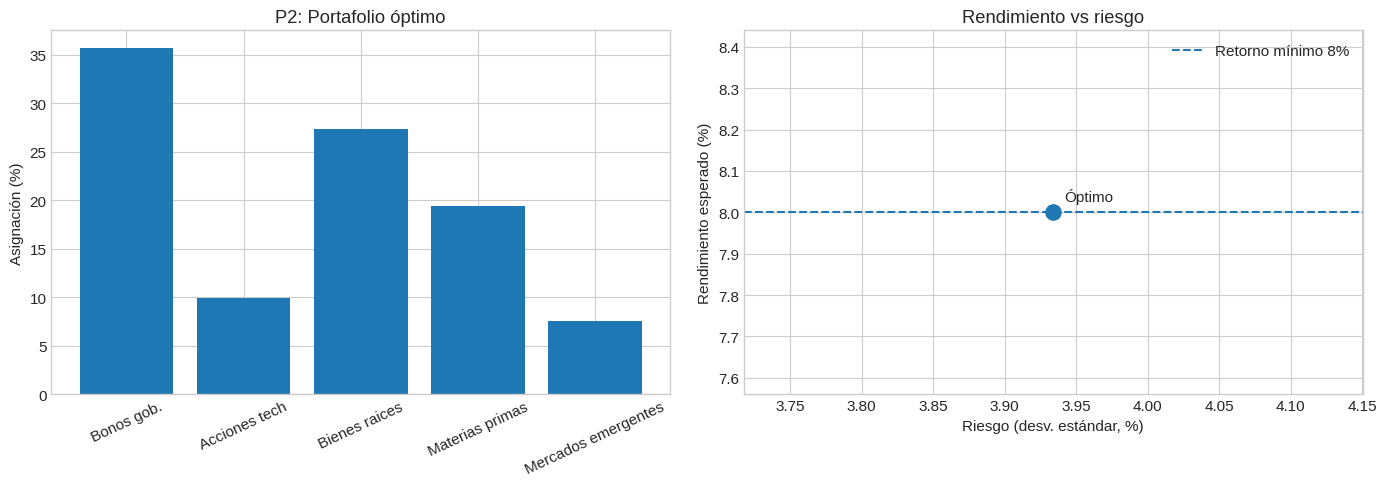

In [10]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===
# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===

def plot_p2(w_opt, varianza_opt):
    """Visualiza la solucion del portafolio.

    Debe mostrar:
    - Panel 1: Barras con la asignacion del portafolio (% por activo)
    - Panel 2: Rendimiento vs riesgo del portafolio optimo

    Args:
        w_opt: np.array (5,)
        varianza_opt: float
    """
    info = verificar_p2(w_opt)
    rendimiento = info["rendimiento"]
    riesgo = np.sqrt(varianza_opt)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1
    axes[0].bar(activos_p2, w_opt * 100)
    axes[0].set_ylabel("Asignación (%)")
    axes[0].set_title("P2: Portafolio óptimo")
    axes[0].tick_params(axis="x", rotation=25)

    # Panel 2
    axes[1].scatter(riesgo * 100, rendimiento * 100, s=120)
    axes[1].annotate("Óptimo", (riesgo * 100, rendimiento * 100),
                     xytext=(8, 8), textcoords="offset points")
    axes[1].set_xlabel("Riesgo (desv. estándar, %)")
    axes[1].set_ylabel("Rendimiento esperado (%)")
    axes[1].set_title("Rendimiento vs riesgo")
    axes[1].axhline(retorno_minimo_p2 * 100, linestyle="--", label="Retorno mínimo 8%")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


w_opt_p2, var_opt_p2 = resolver_p2()
info_p2 = verificar_p2(w_opt_p2)

print(f"Solucion P2:")
for activo, w in zip(activos_p2, w_opt_p2):
    print(f" {activo}: {w*100:.1f}%")
print(f"Rendimiento esperado: {info_p2['rendimiento']*100:.2f}%")
print(f"Varianza: {var_opt_p2:.6f}")
print(f"Desv. estandar: {np.sqrt(var_opt_p2)*100:.2f}%")
print(f"Factible: {info_p2['factible']}")

plot_p2(w_opt_p2, var_opt_p2)

---
## Problema 3: Cobertura con antenas (4 puntos)

Una empresa de telecomunicaciones necesita dar cobertura de senal en **10 zonas** de una ciudad. Existen **7 ubicaciones** posibles para instalar torres de transmision. Cada torre tiene un costo de construccion y cubre un conjunto especifico de zonas (ver tabla).

El objetivo es **seleccionar que torres construir** para cubrir **todas las zonas** al **minimo costo** total. Cada torre se construye completamente o no se construye (decision binaria).

| Torre | Costo (miles \$) | Zonas que cubre |
|:-----:|:----------------:|:---------------:|
| T1    | 50               | 1, 2, 3         |
| T2    | 80               | 2, 3, 4, 5      |
| T3    | 60               | 4, 5, 6         |
| T4    | 70               | 5, 6, 7, 8      |
| T5    | 90               | 7, 8, 9, 10     |
| T6    | 40               | 1, 9, 10        |
| T7    | 75               | 3, 6, 7         |

### 3.1 Formulacion matematica

**Variables de decision:**

Sea $y_i \in \{0,1\}$, donde:
- $y_i = 1$ si se construye la torre $i$
- $y_i = 0$ en otro caso

para $i=1,\dots,7$.

**Funcion objetivo:**

Minimizar el costo total de las torres construidas:

$$\min_{y} \; \sum_{i=1}^7 c_i y_i$$

**Restricciones:**

Sea $a_{ij}=1$ si la torre $i$ cubre la zona $j$, y $0$ en otro caso. Entonces, cada zona debe quedar cubierta al menos una vez:

$$\begin{aligned}
&\sum_{i=1}^7 a_{ij} y_i \ge 1, \quad j=1,\dots,10 \\
&y_i \in \{0,1\}, \quad i=1,\dots,7
\end{aligned}$$

**Optimizador elegido:** `scipy.optimize.milp`

**Justificacion (2-3 oraciones):**  
Este problema es de cobertura mínima (set cover) con variables binarias y restricciones lineales, por lo que se modela naturalmente como un MILP binario. `milp` es adecuado porque permite imponer integridad/binareidad y encontrar una solucion global optima.

### 3.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**

**Justificacion (2-3 oraciones):**

In [11]:
# === DATOS PROBLEMA 3 (NO MODIFICAR) ===
n_torres_p3 = 7
n_zonas_p3 = 10
costos_torres_p3 = np.array([50, 80, 60, 70, 90, 40, 75])
nombres_torres_p3 = [f"T{i+1}" for i in range(n_torres_p3)]

# cobertura_p3[i, j] = 1 si torre i cubre zona j+1
cobertura_p3 = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # T1: zonas 1,2,3
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # T2: zonas 2,3,4,5
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],  # T3: zonas 4,5,6
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],  # T4: zonas 5,6,7,8
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],  # T5: zonas 7,8,9,10
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # T6: zonas 1,9,10
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],  # T7: zonas 3,6,7
])

In [12]:
# === IMPLEMENTACION PROBLEMA 3 ===

def objetivo_p3(y):
    """Calcula el costo total de las torres seleccionadas.

    Args:
        y: np.array (7,) -- variables binarias (o continuas cercanas a 0/1)

    Returns:
        float -- costo total
    """
    y = np.asarray(y, dtype=float)
    return float(costos_torres_p3 @ y)


def verificar_p3(y):
    """Verifica si la seleccion de torres cubre TODAS las zonas.

    Args:
        y: np.array (7,) -- variables de seleccion

    Returns:
        dict con:
          'factible': bool
          'zonas_cubiertas': list
          'zonas_sin_cubrir': list
    """
    y = np.asarray(y, dtype=float)
    y_bin = (y > 0.5).astype(int)

    # cobertura_p3: filas = torres, columnas = zonas
    cobertura_total = y_bin @ cobertura_p3  # (n_zonas,)
    zonas_cubiertas = [j + 1 for j in range(n_zonas_p3) if cobertura_total[j] >= 1]
    zonas_sin_cubrir = [j + 1 for j in range(n_zonas_p3) if cobertura_total[j] < 1]

    return {
        "factible": len(zonas_sin_cubrir) == 0,
        "zonas_cubiertas": zonas_cubiertas,
        "zonas_sin_cubrir": zonas_sin_cubrir,
    }


def resolver_p3():
    """Resuelve el problema de cobertura con antenas.

    Returns:
        y_opt: np.array (7,) -- seleccion optima de torres (0/1)
        costo_opt: float -- costo minimo
    """
    c = costos_torres_p3.astype(float)

    # Para cada zona j: sum_i a_ij y_i >= 1
    A = cobertura_p3.T.astype(float)  # (n_zonas, n_torres)
    cons = [LinearConstraint(A, lb=np.ones(n_zonas_p3), ub=np.full(n_zonas_p3, np.inf))]

    res = milp(
        c=c,
        integrality=np.ones(n_torres_p3, dtype=int),  # enteras
        bounds=Bounds(np.zeros(n_torres_p3), np.ones(n_torres_p3)),  # binarias por cotas
        constraints=cons
    )

    if not res.success:
        raise RuntimeError(f"No se pudo resolver P3: {res.message}")

    y_opt = res.x
    costo_opt = float(res.fun)
    return y_opt, costo_opt

Solucion P3:
 T1: 0
 T2: 1
 T3: 0
 T4: 1
 T5: 0
 T6: 1
 T7: 0
Costo total: 190.00
Zonas cubiertas: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Zonas sin cubrir: []
Factible: True


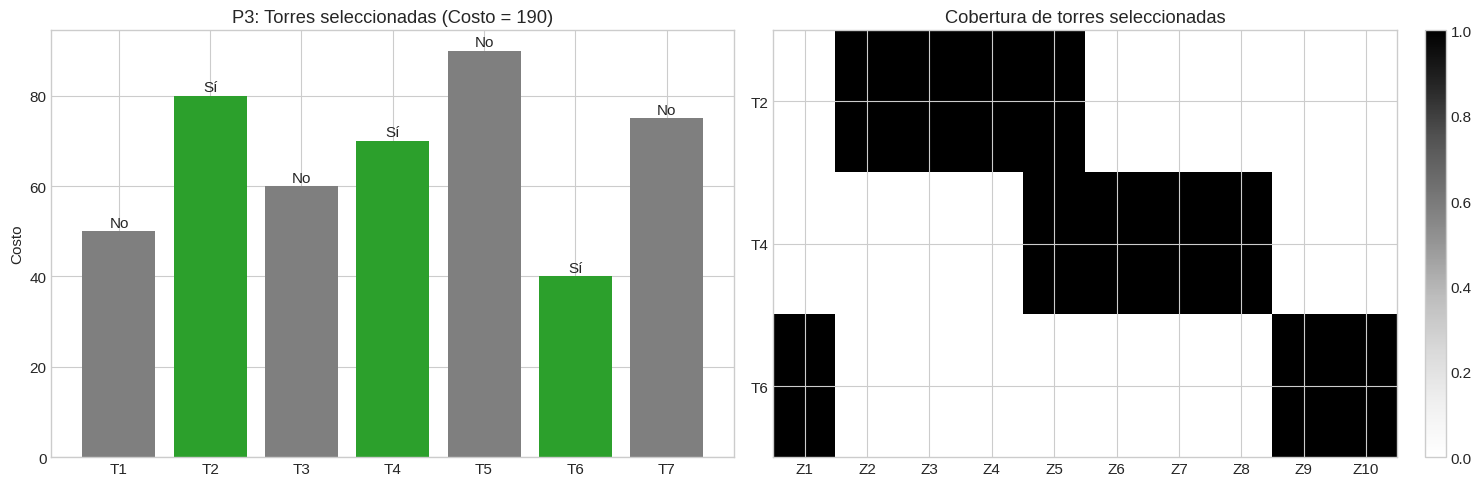

In [13]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

def plot_p3(y_opt, costo_opt):
    """Visualiza la seleccion de torres y la cobertura."""
    y_bin = (np.asarray(y_opt) > 0.5).astype(int)
    seleccionadas = np.where(y_bin == 1)[0]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Panel 1: torres seleccionadas
    colors = ["tab:green" if y_bin[i] else "tab:gray" for i in range(n_torres_p3)]
    axes[0].bar(nombres_torres_p3, costos_torres_p3, color=colors)
    axes[0].set_title(f"P3: Torres seleccionadas (Costo = {costo_opt:.0f})")
    axes[0].set_ylabel("Costo")
    for i, yi in enumerate(y_bin):
        axes[0].text(i, costos_torres_p3[i] + 1, "Sí" if yi else "No", ha="center")

    # Panel 2: matriz de cobertura de seleccionadas
    if len(seleccionadas) > 0:
        mat = cobertura_p3[seleccionadas, :]
        im = axes[1].imshow(mat, aspect="auto")
        axes[1].set_yticks(range(len(seleccionadas)))
        axes[1].set_yticklabels([nombres_torres_p3[i] for i in seleccionadas])
        axes[1].set_xticks(range(n_zonas_p3))
        axes[1].set_xticklabels([f"Z{j+1}" for j in range(n_zonas_p3)])
        axes[1].set_title("Cobertura de torres seleccionadas")
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    else:
        axes[1].text(0.5, 0.5, "No hay torres seleccionadas", ha="center", va="center")
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()


y_opt_p3, costo_opt_p3 = resolver_p3()
info_p3 = verificar_p3(y_opt_p3)

print("Solucion P3:")
for nombre, yi in zip(nombres_torres_p3, (y_opt_p3 > 0.5).astype(int)):
    print(f" {nombre}: {yi}")
print(f"Costo total: {costo_opt_p3:.2f}")
print(f"Zonas cubiertas: {info_p3['zonas_cubiertas']}")
print(f"Zonas sin cubrir: {info_p3['zonas_sin_cubrir']}")
print(f"Factible: {info_p3['factible']}")

plot_p3(y_opt_p3, costo_opt_p3)

---
## Problema 4: Calibracion de sensor (4 puntos)

Un ingeniero necesita calibrar un sensor cuya respuesta sigue el modelo:

$$y(t) = a \cdot \sin(b \cdot t + c) + d \cdot e^{-0.1 \cdot t}$$

donde $a, b, c, d$ son parametros desconocidos y $t$ es la posicion del sensor.

Se tienen **20 mediciones** del sensor en posiciones conocidas (ver datos). El objetivo es encontrar los parametros $a, b, c, d$ que **minimicen el error** entre las predicciones del modelo y las mediciones observadas.

**Nota:** El paisaje de error tiene **multiples minimos locales** debido a los terminos trigonometricos.

**Cotas de los parametros:** $a \in [0, 5]$, $b \in [0, 10]$, $c \in [0, 2\pi]$, $d \in [-3, 3]$

### 4.1 Formulacion matematica

**Variables de decision:**

$$\theta = (a,b,c,d)^\top$$

con cotas:
$$a \in [0,5], \quad b \in [0,10], \quad c \in [0,2\pi], \quad d \in [-3,3]$$

**Funcion objetivo:**

Minimizar el error cuadratico total entre observaciones y el modelo:

$$\min_{\theta} \; \sum_{i=1}^{n} \left(y_i^{obs} - \left[a\sin(b t_i + c) + d e^{-0.1 t_i}\right]\right)^2$$

**Restricciones:**

$$\begin{aligned}
&0 \le a \le 5 \\
&0 \le b \le 10 \\
&0 \le c \le 2\pi \\
&-3 \le d \le 3
\end{aligned}$$

**Optimizador elegido:** `scipy.optimize.dual_annealing`

**Justificacion (2-3 oraciones):**  
La funcion objetivo es no convexa debido al termino sinusoidal, por lo que puede tener multiples minimos locales. `dual_annealing` es apropiado porque es un optimizador global con soporte de cotas y reduce la probabilidad de quedar atrapado en soluciones locales malas.

### 4.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**

**Justificacion (2-3 oraciones):**

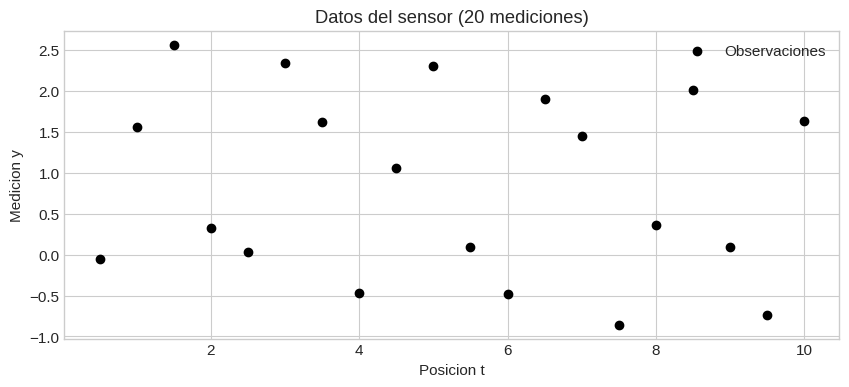

In [14]:
# === DATOS PROBLEMA 4 (NO MODIFICAR) ===

def modelo_sensor(t, params):
    """Modelo del sensor: y = a*sin(b*t + c) + d*exp(-0.1*t)

    Args:
        t: np.array -- posiciones
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        np.array -- predicciones del modelo
    """
    a, b, c, d = params
    return a * np.sin(b * t + c) + d * np.exp(-0.1 * t)

# Posiciones de medicion
t_obs_p4 = np.linspace(0.5, 10.0, 20)

# Mediciones observadas (generadas con parametros ocultos + ruido)
_rng_p4 = np.random.default_rng(2026)
_params_ocultos = _rng_p4.uniform([1, 1, 0, 0.5], [4, 5, 2*np.pi, 3])
y_obs_p4 = modelo_sensor(t_obs_p4, _params_ocultos) + _rng_p4.normal(0, 0.2, 20)
del _rng_p4, _params_ocultos

bounds_p4 = [(0, 5), (0, 10), (0, 2*np.pi), (-3, 3)]

# Visualizar los datos
plt.figure(figsize=(10, 4))
plt.scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
plt.xlabel("Posicion t"); plt.ylabel("Medicion y")
plt.title("Datos del sensor (20 mediciones)")
plt.legend(); plt.show()

In [15]:
# === IMPLEMENTACION PROBLEMA 4 ===

def objetivo_p4(params):
    """Calcula el error entre el modelo y las observaciones.

    Args:
        params: np.array (4,) = [a, b, c, d]

    Returns:
        float -- error cuadratico total (SSE)
    """
    params = np.asarray(params, dtype=float)
    y_pred = modelo_sensor(t_obs_p4, params)
    resid = y_pred - y_obs_p4
    return float(np.sum(resid**2))


def resolver_p4():
    """Resuelve el problema de calibracion del sensor.

    Returns:
        params_opt: np.array (4,) -- parametros optimos [a,b,c,d]
        error_opt: float -- SSE minimo encontrado
    """
    res = dual_annealing(
        objetivo_p4,
        bounds=bounds_p4,
        seed=2026,
        maxiter=300
    )

    # dual_annealing a veces devuelve mensajes distintos; validamos que exista solución
    if not hasattr(res, "x") or not hasattr(res, "fun"):
        raise RuntimeError("No se pudo resolver P4 con dual_annealing.")

    params_opt = np.asarray(res.x, dtype=float)
    error_opt = float(res.fun)
    return params_opt, error_opt

Solucion P4:
Parametros optimos [a,b,c,d] = [1.50896923 3.55302492 2.90577893 1.42541174]
SSE minimo = 0.088386


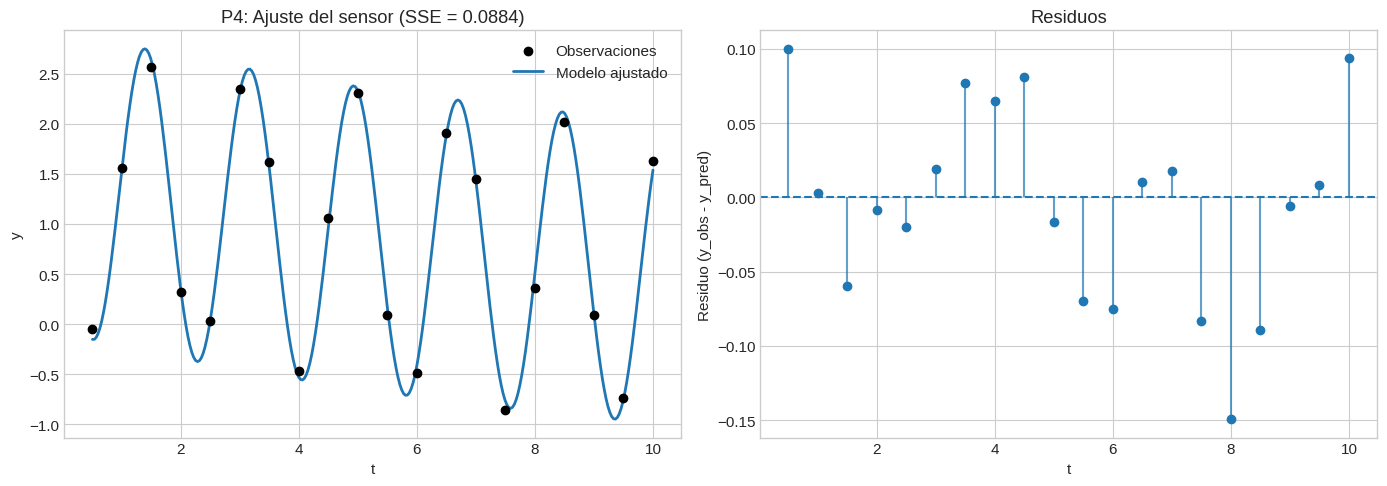

In [16]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===
# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===

def plot_p4(params_opt, error_opt):
    """Visualiza el ajuste del modelo a los datos observados."""
    t_grid = np.linspace(t_obs_p4.min(), t_obs_p4.max(), 300)
    y_fit_grid = modelo_sensor(t_grid, params_opt)
    y_fit_obs = modelo_sensor(t_obs_p4, params_opt)
    resid = y_obs_p4 - y_fit_obs

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: ajuste
    axes[0].scatter(t_obs_p4, y_obs_p4, color="black", label="Observaciones", zorder=5)
    axes[0].plot(t_grid, y_fit_grid, linewidth=2, label="Modelo ajustado")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("y")
    axes[0].set_title(f"P4: Ajuste del sensor (SSE = {error_opt:.4f})")
    axes[0].legend()

    # Panel 2: residuos
    axes[1].axhline(0, linestyle="--")
    axes[1].scatter(t_obs_p4, resid)
    axes[1].vlines(t_obs_p4, 0, resid, alpha=0.7)
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("Residuo (y_obs - y_pred)")
    axes[1].set_title("Residuos")

    plt.tight_layout()
    plt.show()


params_opt_p4, error_opt_p4 = resolver_p4()

print("Solucion P4:")
print(f"Parametros optimos [a,b,c,d] = {params_opt_p4}")
print(f"SSE minimo = {error_opt_p4:.6f}")

plot_p4(params_opt_p4, error_opt_p4)

---
## Problema 5: Red de distribucion (4 puntos)

Una empresa de logistica considera abrir centros de distribucion (CDs) en **4 ciudades** posibles para atender a **6 clientes**. Cada CD tiene un **costo fijo** de apertura, una **capacidad maxima**, y un **costo de envio por unidad** a cada cliente. Cada cliente tiene una **demanda** que debe ser satisfecha completamente.

La empresa debe decidir:
1. **Que CDs abrir** (decision binaria: abrir o no)
2. **Cuantas unidades enviar** de cada CD abierto a cada cliente (decision continua)

El objetivo es **minimizar el costo total** (costos fijos de apertura + costos de envio).

| CD | Ciudad      | Costo fijo (miles \$) | Capacidad |
|:--:|:-----------:|:--------------------:|:---------:|
| 1  | Guadalajara | 800                  | 500       |
| 2  | Monterrey   | 700                  | 400       |
| 3  | CDMX        | 1000                 | 600       |
| 4  | Merida      | 600                  | 350       |

| Cliente | C1  | C2 | C3  | C4  | C5  | C6  |
|:-------:|:---:|:--:|:---:|:---:|:---:|:---:|
| Demanda | 120 | 80 | 200 | 150 | 100 | 180 |

**Costos de envio** (\$ por unidad):

|      | C1 | C2 | C3 | C4 | C5 | C6 |
|:----:|:--:|:--:|:--:|:--:|:--:|:--:|
| GDL  | 4  | 8  | 5  | 9  | 7  | 6  |
| MTY  | 7  | 3  | 6  | 8  | 4  | 9  |
| CDMX | 5  | 6  | 3  | 4  | 8  | 5  |
| MER  | 9  | 7  | 8  | 3  | 6  | 4  |

### 5.1 Formulacion matematica

**Variables de decision:**

- $y_i \in \{0,1\}$: indica si se abre el centro de distribucion (CD) $i$, para $i=1,\dots,4$
- $x_{ij} \ge 0$: unidades enviadas del CD $i$ al cliente $j$, para $j=1,\dots,6$

**Funcion objetivo:**

Minimizar costo total = costo fijo de apertura + costo de envio:

$$\min_{x,y} \; \sum_{i=1}^{4} F_i y_i + \sum_{i=1}^{4}\sum_{j=1}^{6} c_{ij} x_{ij}$$

**Restricciones:**

$$\begin{aligned}
&\sum_{i=1}^{4} x_{ij} = d_j, \quad j=1,\dots,6 && \text{(satisfaccion de demanda)}\\
&\sum_{j=1}^{6} x_{ij} \le \text{Cap}_i \, y_i, \quad i=1,\dots,4 && \text{(capacidad / apertura)}\\
&x_{ij} \ge 0,\quad y_i \in \{0,1\}
\end{aligned}$$

> Nota: si los costos fijos estan en miles de dólares y los costos de envio en dólares por unidad, conviene unificar unidades en la implementacion.



### 5.2 Eleccion de optimizador

**Optimizador elegido:** `scipy.optimize.milp`

**Justificacion (2-3 oraciones):**  
Este problema combina variables binarias (abrir o no cada CD) con variables continuas (flujos de envio), y tanto el objetivo como las restricciones son lineales. Por ello se modela como un MILP mixto, y `milp` permite resolverlo de forma exacta bajo esas condiciones.

In [17]:
# === DATOS PROBLEMA 5 (NO MODIFICAR) ===
ciudades_p5 = ["Guadalajara", "Monterrey", "CDMX", "Merida"]
n_cds_p5 = 4
n_clientes_p5 = 6

costos_fijos_p5 = np.array([800, 700, 1000, 600])    # miles $
capacidades_p5 = np.array([500, 400, 600, 350])
demandas_p5 = np.array([120, 80, 200, 150, 100, 180])

# costos_envio_p5[i, j] = costo de enviar 1 unidad de CD i a cliente j
costos_envio_p5 = np.array([
    [4, 8, 5, 9, 7, 6],   # Guadalajara
    [7, 3, 6, 8, 4, 9],   # Monterrey
    [5, 6, 3, 4, 8, 5],   # CDMX
    [9, 7, 8, 3, 6, 4],   # Merida
])

In [18]:
# === IMPLEMENTACION PROBLEMA 5 ===

def objetivo_p5(y, X):
    """Calcula el costo total: costos fijos + costos de envio.

    Nota:
      - costos_fijos_p5: miles de $
      - costos_envio_p5: $/unidad
    Convertimos envio a miles de $ para que todo quede en la misma unidad.
    """
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)

    costo_fijo = float(costos_fijos_p5 @ y)                 # miles $
    costo_envio = float(np.sum(costos_envio_p5 * X) / 1000) # miles $
    return costo_fijo + costo_envio


def verificar_p5(y, X):
    """Verifica factibilidad de la solucion de red de distribucion.

    Returns:
        dict con:
          'factible': bool
          'demanda_cumplida': np.array (n_clientes,)
          'capacidad_usada': np.array (n_cds,)
    """
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)

    demanda_cumplida = X.sum(axis=0)
    capacidad_usada = X.sum(axis=1)

    tol = 1e-6
    cumple_demandas = np.all(np.abs(demanda_cumplida - demandas_p5) <= 1e-5)
    cumple_capacidad = np.all(capacidad_usada <= capacidades_p5 * y + 1e-5)
    cumple_no_neg = np.all(X >= -tol)
    cumple_y = np.all((y >= -tol) & (y <= 1 + tol))

    return {
        "factible": bool(cumple_demandas and cumple_capacidad and cumple_no_neg and cumple_y),
        "demanda_cumplida": demanda_cumplida,
        "capacidad_usada": capacidad_usada,
    }


def resolver_p5():
    """Resuelve la red de distribucion (MILP mixto).

    Returns:
        y_opt: np.array (n_cds,)
        X_opt: np.array (n_cds, n_clientes)
        costo_opt: float (en miles de $)
    """
    nY = n_cds_p5
    nX = n_cds_p5 * n_clientes_p5
    nvars = nY + nX

    # vector de decisión z = [y_0,...,y_{nY-1}, x_00,...,x_0m, x_10,...]
    c = np.concatenate([
        costos_fijos_p5.astype(float),                       # miles $
        (costos_envio_p5.astype(float).ravel() / 1000.0)     # miles $/unidad
    ])

    integrality = np.concatenate([
        np.ones(nY, dtype=int),   # y enteras (con bounds [0,1] => binarias)
        np.zeros(nX, dtype=int)   # x continuas
    ])

    lb = np.zeros(nvars)
    ub = np.concatenate([
        np.ones(nY),
        np.full(nX, np.inf)
    ])

    constraints = []

    # 1) Demandas: sum_i x_ij = demanda_j
    A_dem = np.zeros((n_clientes_p5, nvars))
    for j in range(n_clientes_p5):
        for i in range(n_cds_p5):
            idx_x = nY + i * n_clientes_p5 + j
            A_dem[j, idx_x] = 1.0
    constraints.append(LinearConstraint(A_dem, lb=demandas_p5, ub=demandas_p5))

    # 2) Capacidad ligada a apertura: sum_j x_ij - cap_i y_i <= 0
    A_cap = np.zeros((n_cds_p5, nvars))
    for i in range(n_cds_p5):
        A_cap[i, i] = -capacidades_p5[i]
        for j in range(n_clientes_p5):
            idx_x = nY + i * n_clientes_p5 + j
            A_cap[i, idx_x] = 1.0
    constraints.append(
        LinearConstraint(A_cap, lb=np.full(n_cds_p5, -np.inf), ub=np.zeros(n_cds_p5))
    )

    res = milp(
        c=c,
        integrality=integrality,
        bounds=Bounds(lb, ub),
        constraints=constraints
    )

    if not res.success:
        raise RuntimeError(f"No se pudo resolver P5: {res.message}")

    z_opt = res.x
    y_opt = z_opt[:nY]
    X_opt = z_opt[nY:].reshape(n_cds_p5, n_clientes_p5)
    costo_opt = float(res.fun)  # miles $

    return y_opt, X_opt, costo_opt

Solucion P5:
 Guadalajara: Abrir
 Monterrey: No abrir
 CDMX: No abrir
 Merida: Abrir
Costo total (miles $): 1403.970
Capacidad usada por CD: [480.   0.   0. 350.]
Demanda atendida por cliente: [120.  80. 200. 150. 100. 180.]
Factible: True


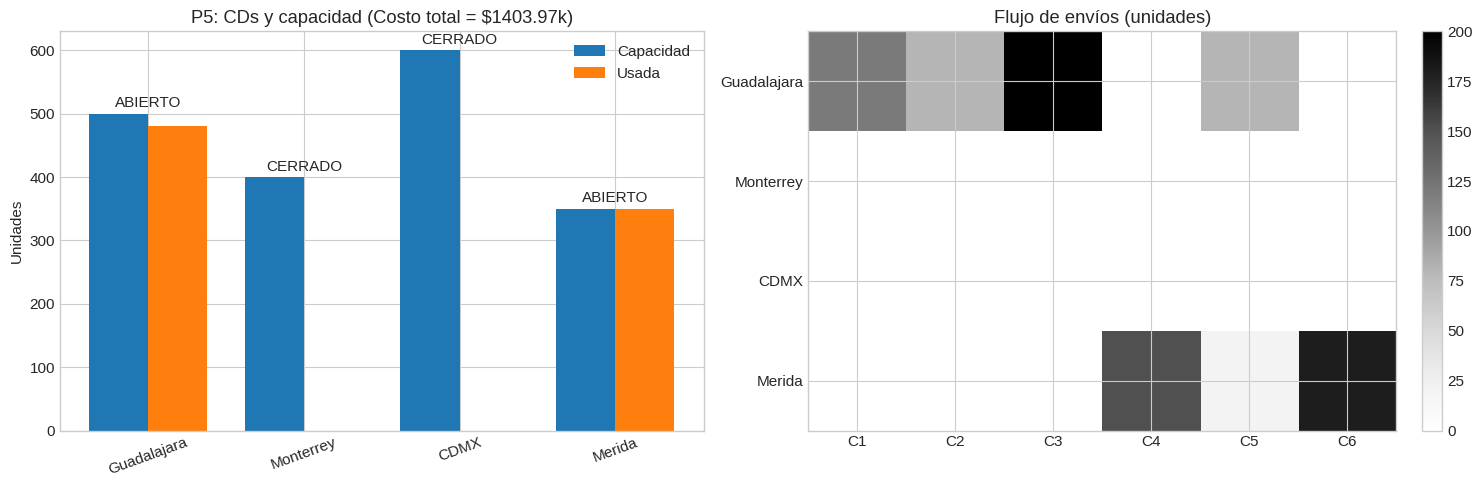

In [19]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 5 ===

def plot_p5(y_opt, X_opt, costo_opt):
    """Visualiza la red de distribucion."""
    y_bin = (np.asarray(y_opt) > 0.5).astype(int)
    cap_usada = X_opt.sum(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Panel 1: capacidad vs uso
    x = np.arange(n_cds_p5)
    w = 0.38
    axes[0].bar(x - w/2, capacidades_p5, width=w, label="Capacidad")
    axes[0].bar(x + w/2, cap_usada, width=w, label="Usada")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(ciudades_p5, rotation=20)
    axes[0].set_ylabel("Unidades")
    axes[0].set_title(f"P5: CDs y capacidad (Costo total = ${costo_opt:.2f}k)")
    for i in range(n_cds_p5):
        estado = "ABIERTO" if y_bin[i] else "CERRADO"
        axes[0].text(i, max(capacidades_p5[i], cap_usada[i]) + 10, estado, ha="center")
    axes[0].legend()

    # Panel 2: matriz de envíos
    im = axes[1].imshow(X_opt, aspect="auto")
    axes[1].set_yticks(range(n_cds_p5))
    axes[1].set_yticklabels(ciudades_p5)
    axes[1].set_xticks(range(n_clientes_p5))
    axes[1].set_xticklabels([f"C{j+1}" for j in range(n_clientes_p5)])
    axes[1].set_title("Flujo de envíos (unidades)")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


y_opt_p5, X_opt_p5, costo_opt_p5 = resolver_p5()
info_p5 = verificar_p5(y_opt_p5, X_opt_p5)

print("Solucion P5:")
for ciudad, yi in zip(ciudades_p5, (y_opt_p5 > 0.5).astype(int)):
    print(f" {ciudad}: {'Abrir' if yi else 'No abrir'}")
print(f"Costo total (miles $): {costo_opt_p5:.3f}")
print("Capacidad usada por CD:", info_p5["capacidad_usada"])
print("Demanda atendida por cliente:", info_p5["demanda_cumplida"])
print(f"Factible: {info_p5['factible']}")

plot_p5(y_opt_p5, X_opt_p5, costo_opt_p5)